<h5 style="font-size:14px;">

**Definiție:** Regresia logistică este o metodă statistică utilizată pentru probleme de clasificare, în special pentru clasificare binară. Ea modelează probabilitatea ca o observație să aparțină unei clase folosind funcția logistică (sigmoidă). Deși se numește „regresie”, este folosită în principal pentru clasificare.  

**Tipuri:**<br>
- **Regresie logistică binară:** clasifică datele în două clase (ex: 0 și 1).<br>
- **Regresie logistică multinomială:** utilizată pentru clasificare multiclasă (mai mult de două clase).<br>
- **Regresie logistică ordinală:** utilizată când variabila dependentă are categorii ordonate.<br>

**Elemente teoretice:**<br>
- **Funcția sigmoidă (logistică):** transformă rezultatul liniar într-o probabilitate între 0 și 1.<br>
- **z = β₀ + β₁X₁ + ... + βₚXₚ:** combinația liniară a variabilelor independente.<br>
- **β (coeficienți):** indică influența fiecărei variabile asupra log-odds-ului.<br>
- **Log-odds (logit):** log(p / (1 - p)), unde p este probabilitatea clasei 1.<br>
- **p (probabilitate estimată):** șansa ca observația să aparțină clasei pozitive.<br>

**Presupuneri ale regresiei logistice:**<br>
- Relația dintre variabilele independente și log-odds este liniară.<br>
- Observațiile sunt independente.<br>
- Nu există multicoliniaritate puternică între variabile.<br>
- Dimensiunea eșantionului este suficient de mare.<br><br>

</h5>

<h5 style="font-size:14px;">

**Descrierea setului de date:** Setul de date *Titanic* conține informații despre pasagerii care se aflau la bordul navei Titanic, inclusiv caracteristici demografice și informații despre bilete. Datele sunt folosite pentru analiza supraviețuirii pasagerilor în urma tragediei.

**Structura datelor:**<br>
- **PassengerId:** identificator unic al pasagerului.<br>
- **Survived:** indică dacă pasagerul a supraviețuit (1 = da, 0 = nu).<br>
- **Pclass:** clasa pasagerului (1 = întâi, 2 = a doua, 3 = a treia).<br>
- **Name:** numele complet al pasagerului.<br>
- **Sex:** genul pasagerului (male/female).<br>
- **Age:** vârsta pasagerului (în ani).<br>
- **SibSp:** numărul de frați sau soți/soții aflați la bord.<br>
- **Parch:** numărul de părinți sau copii aflați la bord.<br>
- **Ticket:** numărul biletului.<br>
- **Fare:** prețul biletului.<br>
- **Cabin:** cabina atribuită pasagerului (dacă există).<br>
- **Embarked:** portul de îmbarcare (C = Cherbourg, Q = Queenstown, S = Southampton).<br>

**Variabile numerice utilizate în analiză:**<br>
- **Age** – vârsta pasagerului.<br>
- **SibSp** – numărul de frați/soți.<br>
- **Parch** – numărul de părinți/copii.<br>
- **Fare** – prețul biletului.<br>

</h5>

regresia logistică este despre a prezice date binare 0 și 1
ex: prezice de prezența (1) / absența (0) unei boli sau apartenența (1) /non-apartenența (0) la o clasă.
1. Importarea librăriilor necesare;
2. Citirea fișierului;
3. Analiza exploratorie a datelor (EDA);
4. Divizarea setului de date în date de antrenare și date de testare;
5. Importarea și implementarea modelului;
6. Evaluarea și dacă e posibil ameliorarea rezultatelor obținute.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

In [4]:
train = pd.read_csv('../data/train.csv')

In [5]:
train.head(12)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


Heatmap -  vedem datele lipsa

In [6]:
train.tail(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
881,882,0,3,"Markun, Mr. Johann",male,33.0,0,0,349257,7.8958,NaN,S
882,883,0,3,"Dahlberg, Miss. Gerda Ulrika",female,22.0,0,0,7552,10.5167,NaN,S
883,884,0,2,"Banfield, Mr. Frederick James",male,28.0,0,0,C.A./SOTON 34068,10.5000,NaN,S
884,885,0,3,"Sutehall, Mr. Henry Jr",male,25.0,0,0,SOTON/OQ 392076,7.0500,NaN,S
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,NaN,Q
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.7500,NaN,Q


In [7]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
train.shape

(891, 12)

In [9]:
train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [10]:
train.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

In [11]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [12]:
print(train.duplicated().sum())

0


In [13]:
train.nunique()

PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64

<Axes: >

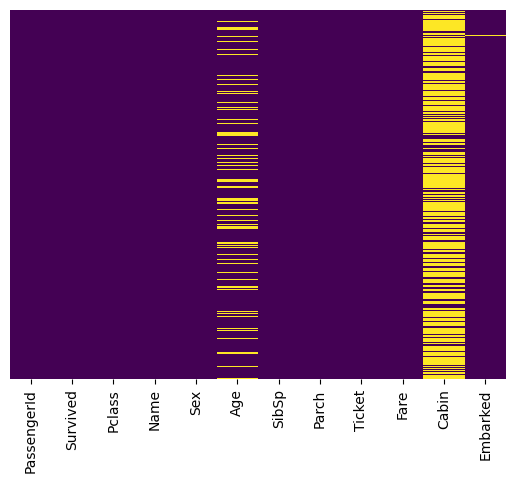

In [14]:
sns.heatmap(train.isnull(), yticklabels=False, cbar=False, cmap='viridis')


aproximativ 20% din datele privind vârsta ('Age')
lipsesc, iar din coloana 'Cabin', lipsesc pur și simplu prea multe date pentru a face ceva util cu
ele la nivel de bază.

 Reprezentarea grafică a datelor 'Survived' cu countplot()

/var/folders/r3/5pjmqzwx5kd217gbxkm_5yxm0000gn/T/ipykernel_1572/3484660399.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=train, palette='RdBu_r')


<Axes: xlabel='Survived', ylabel='count'>

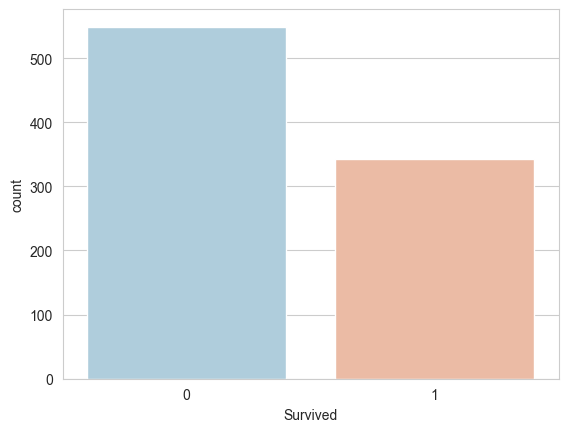

In [15]:
sns.set_style('whitegrid')
sns.countplot(x='Survived', data=train, palette='RdBu_r')

Pe cateogrii:

<Axes: xlabel='Survived', ylabel='count'>

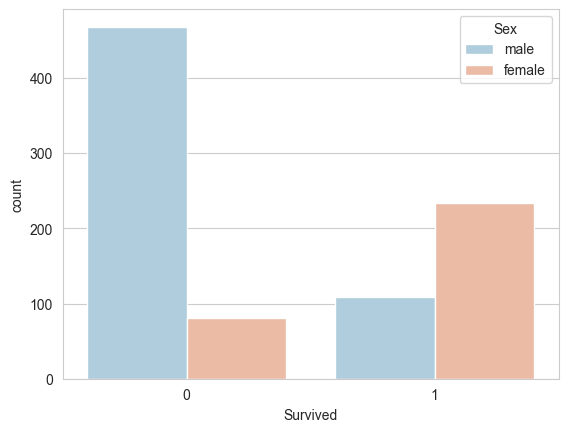

In [16]:
sns.set_style('whitegrid')
sns.countplot(x='Survived', hue='Sex', data=train, palette='RdBu_r')

<Axes: xlabel='Survived', ylabel='count'>

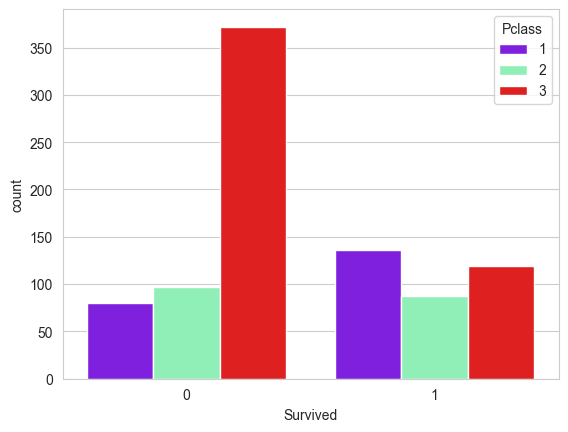

In [17]:
sns.set_style('whitegrid')
sns.countplot(x='Survived', hue='Pclass', data=train, palette='rainbow')

Vizualizarea după vârstă a pasagerilor Titanicului

<Axes: >

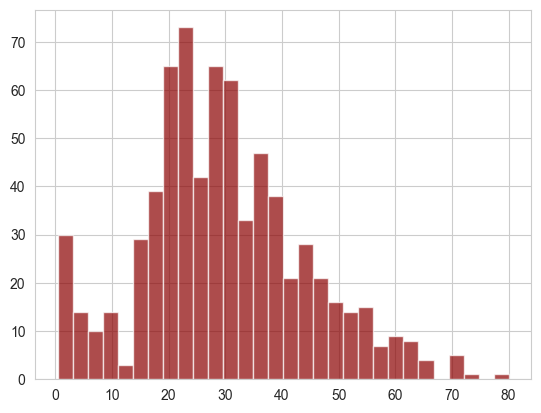

In [18]:
train['Age'].hist(bins=30, color='darkred', alpha=0.7)

Curatarea datelor

/var/folders/r3/5pjmqzwx5kd217gbxkm_5yxm0000gn/T/ipykernel_1572/677368235.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Pclass', y='Age', data=train, palette='winter')


<Axes: xlabel='Pclass', ylabel='Age'>

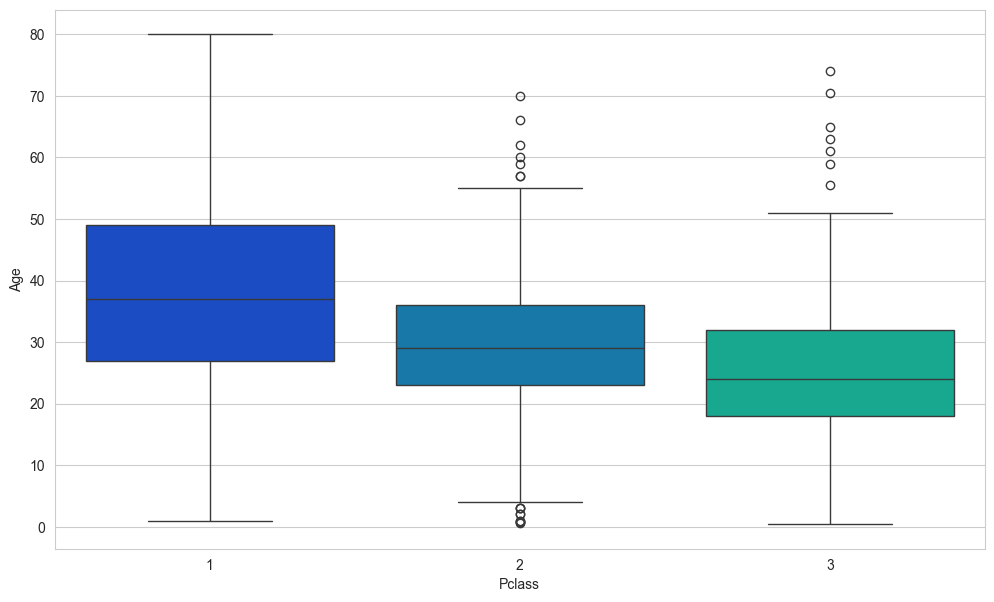

In [19]:
#Verificăm vârsta medie în funcție de clasa de pasageri
plt.figure(figsize=(12, 7))
sns.boxplot(x='Pclass', y='Age', data=train, palette='winter')

se observă că persoanele tinere călătoresc la clasa 3, iar cele mai în
vârstă – la clasa 1.

Creăm o funcție care atribuie persoanelor fiecărei clase valoarea medianei din
reprezentarea grafică:

In [20]:
def impute_age(cols):
    Age = cols['Age']
    Pclass = cols['Pclass']

    if pd.isnull(Age):
        if Pclass == 1:
            return 37
        elif Pclass == 2:
            return 29
        else:
            return 24
    else:
         return Age


In [21]:
train['Age'] = train[['Age', 'Pclass']].apply(impute_age, axis=1)

<Axes: >

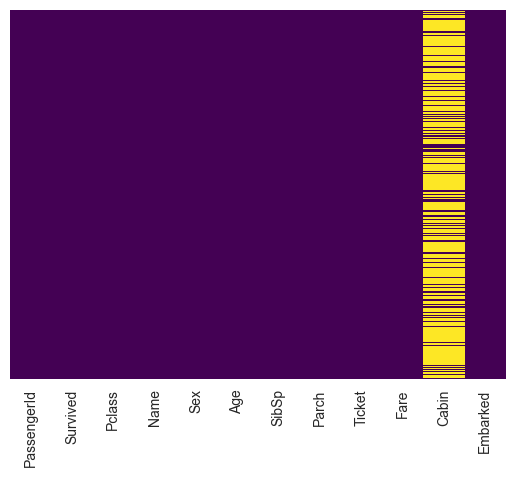

In [22]:
sns.heatmap(train.isnull(), yticklabels=False, cbar=False, cmap='viridis')

In [23]:
train.drop('Cabin',axis=1,inplace=True)

In [24]:
train.dropna(inplace=True)

<Axes: >

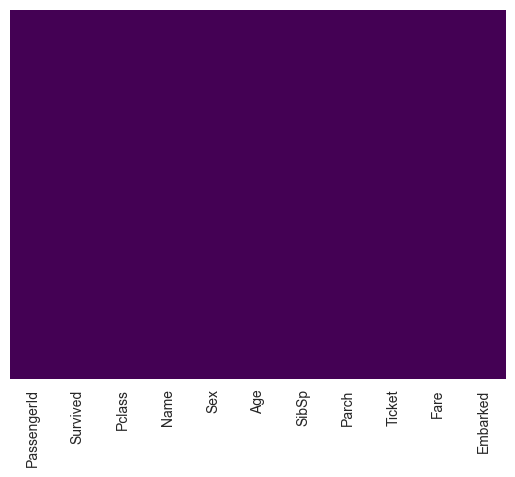

In [25]:
sns.heatmap(train.isnull(), yticklabels=False, cbar=False, cmap='viridis')

Conversia caracteristicilor
se folosește funcția get_dummies() din librăria pandas sau
LabelEncoder() din sklearn.

In [26]:
train.info()

<class 'pandas.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  889 non-null    int64  
 1   Survived     889 non-null    int64  
 2   Pclass       889 non-null    int64  
 3   Name         889 non-null    str    
 4   Sex          889 non-null    str    
 5   Age          889 non-null    float64
 6   SibSp        889 non-null    int64  
 7   Parch        889 non-null    int64  
 8   Ticket       889 non-null    str    
 9   Fare         889 non-null    float64
 10  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(4)
memory usage: 83.3 KB


In [27]:
sex = pd.get_dummies(train['Sex'],drop_first=True).astype('uint8')
embark = pd.get_dummies(train['Embarked'],drop_first= True).astype('uint8')

In [28]:
train.drop(['Sex','Embarked','Name','Ticket'],axis=1, inplace=True)
train = pd.concat([train, sex, embark],axis=1)

In [29]:
train.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,male,Q,S
0,1,0,3,22.0,1,0,7.2500,1,0,1
1,2,1,1,38.0,1,0,71.2833,0,0,0
2,3,1,3,26.0,0,0,7.9250,0,0,1
3,4,1,1,35.0,1,0,53.1000,0,0,1
4,5,0,3,35.0,0,0,8.0500,1,0,1


Acum setul de date este pregătit pentru prelucrarea automată. Se construiește modelul de
regresie logistică.

In [30]:
train.info()

<class 'pandas.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  889 non-null    int64  
 1   Survived     889 non-null    int64  
 2   Pclass       889 non-null    int64  
 3   Age          889 non-null    float64
 4   SibSp        889 non-null    int64  
 5   Parch        889 non-null    int64  
 6   Fare         889 non-null    float64
 7   male         889 non-null    uint8  
 8   Q            889 non-null    uint8  
 9   S            889 non-null    uint8  
dtypes: float64(2), int64(5), uint8(3)
memory usage: 58.2 KB


In [31]:
X_train, X_test, y_train, y_test = train_test_split(train.drop('Survived',axis=1), train['Survived'], test_size=0.30,random_state=101)

In [32]:
print("training test size:", X_train.shape)
print("test set size:", X_test.shape)

training test size: (622, 9)
test set size: (267, 9)


In [33]:
logmodel = LogisticRegression()

logmodel.fit(X_train,y_train)

predictions = logmodel.predict(X_test)

/Users/alexandramanea/OneDriveBackup/UTM/anul 3/sem2/IA/Artificial_Intelligence/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [34]:
print(confusion_matrix(y_test, predictions))

[[148  15]
 [ 39  65]]


In [35]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.79      0.91      0.85       163
           1       0.81      0.62      0.71       104

    accuracy                           0.80       267
   macro avg       0.80      0.77      0.78       267
weighted avg       0.80      0.80      0.79       267

